# 06 — PSM + DiD Analysis (v2)

Runs propensity-score matching and difference-in-differences regression
using the v2 panel (pre/post design, SVM mh_score outcome).

**Inputs:**
- `data/processed/{SUBREDDIT}/panel_scores.parquet` (from notebook 04)
- `data/processed/{SUBREDDIT}/user_community_breadth.parquet` (from notebook 05)

**Research questions:**
- **RQ1**: Does exposure to negative anchor posts increase mental-health distress language?
  `mh_score ~ period + exposed + period×exposed + log1p(n_posts)`, HC3 SEs
- **RQ2**: Does community breadth moderate the effect?
  Full three-way interaction with `community_breadth_log`

**Design:**
- Pre period: Sep–Nov of each cycle year (before first anchor comment for exposed)
- Post period: December–May of each cycle year
- PSM: 1:1 nearest-neighbor on `pre_mh_score` + `pre_n_posts`
- Cross-cycle replication: one ATT per admission cycle + pooled (+ cycle FE).
  Cycles are derived dynamically from the panel — works for 2 or 3 (or more) cycles.

In [1]:
# ── CONFIG ───────────────────────────────────────────────────────────────────
STUDY_ID  = 'mba'
SUBREDDIT = 'mba'   # change to 'mscs' for MSCS pipeline

# Admission cycles (numbered chronologically, must match NB03/NB04).
#   Cycle 1: Aug 2022 – May 2023
#   Cycle 2: Aug 2023 – May 2024
#   Cycle 3: Aug 2024 – May 2025
# `tight_post_end` = last day of Dec–Jan for the robustness tight-window test.
CYCLES = {
    1: {'post_end': '2023-05-31', 'tight_post_end': '2023-01-31'},
    2: {'post_end': '2024-05-31', 'tight_post_end': '2024-01-31'},
    3: {'post_end': '2025-05-31', 'tight_post_end': '2025-01-31'},
}
CYCLE_KEYS = sorted(CYCLES.keys())

# PSM parameters
PSM_CALIPER               = 0.05
PSM_FEATURES_BASE         = ['pre_mh_score', 'log1p_n_posts_pre']
BREADTH_COVERAGE_THRESHOLD = 0.95

# Treatment variables
PRIMARY_TREATMENT   = 'exposure_intensity'   # continuous (BART top-neg score, 0–1)
SECONDARY_TREATMENT = 'exposure_prob'         # popularity-weighted [0,1]

# GPS covariates for Hirano-Imbens weighting
GPS_COVARIATES = ['pre_mh_score', 'log1p_n_posts_pre', 'community_breadth_log']

# Outcome dimensions for per-dim DiD
OUTCOME_DIMS = ['mh_score', 'anx_score', 'dep_score', 'str_score']

# Robustness: tight post-window
TIGHT_POST_MONTHS = [12, 1]
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

ROOT    = Path('..'  ).resolve()
DATA  = ROOT / 'data' / 'processed' / SUBREDDIT
FIGURES  = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)
FIG_DIR = FIGURES  # alias for legacy cells

panel   = pd.read_parquet(DATA / 'panel_scores.parquet')
breadth = pd.read_parquet(DATA / 'user_community_breadth.parquet')

# exposure_prob lives in labels but wasn't carried through NB04 — merge it in
labels = pd.read_parquet(DATA / 'exposure_labels.parquet')
panel = panel.merge(
    labels[['author', 'cycle', 'exposure_prob']],
    on=['author', 'cycle'], how='left'
)
panel['exposure_prob'] = panel['exposure_prob'].fillna(0.0)

print(f'Panel rows  : {len(panel):,}')
print(f'Unique users: {panel["author"].nunique():,}')
print(f'Exposed     : {panel[panel["exposed"]==True]["author"].nunique():,}')
print(f'exposure_intensity range: {panel["exposure_intensity"].min()}–{panel["exposure_intensity"].max()}')
print(f'exposure_prob range     : {panel["exposure_prob"].min():.3f}–{panel["exposure_prob"].max():.3f}')


Panel rows  : 10,338
Unique users: 9,229
Exposed     : 1,891
exposure_intensity range: 0.0–0.9643643498420715
exposure_prob range     : 0.000–1.000


## 1) Merge with community breadth

In [3]:
panel = panel.merge(
    breadth[['author', 'community_breadth', 'community_breadth_log']],
    on='author', how='left'
)
breadth_coverage = panel['community_breadth'].notna().mean()
print(f'Community breadth coverage: {breadth_coverage:.1%}')
panel['log1p_n_posts_pre'] = np.log1p(panel['pre_n_posts'])

Community breadth coverage: 99.5%


## 2) PSM — per cycle

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

breadth_coverage = panel['community_breadth'].notna().mean()
print(f'Community breadth coverage: {breadth_coverage:.1%}')
panel['log1p_n_posts_pre'] = np.log1p(panel['pre_n_posts'].fillna(0))

MATCH_FEATURES = list(PSM_FEATURES_BASE)
if breadth_coverage >= BREADTH_COVERAGE_THRESHOLD:
    MATCH_FEATURES.append('community_breadth_log')
    print('Including community_breadth_log in PSM features')
else:
    print('Breadth coverage below threshold — omitting from PSM')

def compute_smd(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.std()**2 + b.std()**2) / 2 + 1e-9)

matched_by_cycle = {}
for cycle in panel['cycle'].unique():
    cyc = panel[panel['cycle'] == cycle].copy()
    exp  = cyc[cyc['exposed'] == True]
    ctrl = cyc[cyc['exposed'] == False]

    scaler = StandardScaler()
    X_exp  = scaler.fit_transform(exp[MATCH_FEATURES].fillna(0))
    X_ctrl = scaler.transform(ctrl[MATCH_FEATURES].fillna(0))

    lr = LogisticRegression(max_iter=1000)
    all_X = np.vstack([X_exp, X_ctrl])
    all_y = np.array([1]*len(X_exp) + [0]*len(X_ctrl))
    lr.fit(all_X, all_y)
    ps_exp  = lr.predict_proba(X_exp)[:,1]
    ps_ctrl = lr.predict_proba(X_ctrl)[:,1]

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(ps_ctrl.reshape(-1,1))
    distances, indices = nn.kneighbors(ps_exp.reshape(-1,1))

    matched = []
    used_ctrl = set()
    for i, (dist, idx) in enumerate(zip(distances[:,0], indices[:,0])):
        if dist <= PSM_CALIPER and idx not in used_ctrl:
            matched.append((exp.iloc[i]['author'], ctrl.iloc[idx]['author']))
            used_ctrl.add(idx)

    matched_authors = set([a for a,b in matched] + [b for a,b in matched])
    matched_by_cycle[cycle] = matched_authors
    print(f'Cycle {cycle}: {len(matched):,} matched pairs  (caliper={PSM_CALIPER})')

    # SMD check
    matched_cyc = cyc[cyc['author'].isin(matched_authors)]
    for feat in MATCH_FEATURES:
        smd = compute_smd(
            matched_cyc[matched_cyc['exposed']==True][feat].dropna(),
            matched_cyc[matched_cyc['exposed']==False][feat].dropna()
        )
        print(f'  SMD {feat}: {smd:.4f}')


Community breadth coverage: 99.5%
Including community_breadth_log in PSM features
Cycle 1: 369 matched pairs  (caliper=0.05)
  SMD pre_mh_score: 0.0319
  SMD log1p_n_posts_pre: 0.0301
  SMD community_breadth_log: -0.0618
Cycle 2: 622 matched pairs  (caliper=0.05)
  SMD pre_mh_score: -0.0538
  SMD log1p_n_posts_pre: 0.0182
  SMD community_breadth_log: 0.0168
Cycle 3: 538 matched pairs  (caliper=0.05)
  SMD pre_mh_score: -0.0292
  SMD log1p_n_posts_pre: -0.0428
  SMD community_breadth_log: 0.0923


## 3) Reshape to long format

In [5]:
# Build long-format DiD dataframe — dynamic over all cycles present in panel
panel_cycles = sorted(int(c) for c in panel['cycle'].dropna().unique())

long_rows = []
for cycle in panel_cycles:
    sub = panel[
        (panel['cycle'] == cycle) &
        (panel['author'].isin(matched_by_cycle.get(cycle, set())))
    ]
    for _, row in sub.iterrows():
        base = {
            'author':             row['author'],
            'cycle':              cycle,
            'exposed':            bool(row['exposed']),
            'exposure_intensity': float(row.get('exposure_intensity', 0.0)),
            'exposure_prob':      float(row.get('exposure_prob', 0.0)),
            'community_breadth_log': row.get('community_breadth_log', np.nan),
            'log1p_n_posts_pre':  row.get('log1p_n_posts_pre', 0),
        }
        for period_val, window in [(0, 'pre'), (1, 'post')]:
            r = dict(base)
            r['period']  = period_val
            r['window']  = window
            r['mh_score']  = row.get(f'{window}_mh_score')
            r['anx_score'] = row.get(f'{window}_anx_score')
            r['dep_score'] = row.get(f'{window}_dep_score')
            r['str_score'] = row.get(f'{window}_str_score')
            r['log1p_n_posts'] = np.log1p(row.get(f'{window}_n_posts', 0))
            long_rows.append(r)

long_df = pd.DataFrame(long_rows)
long_df['period_x_exposed']   = long_df['period'] * long_df['exposed'].astype(int)
long_df['period_x_intensity'] = long_df['period'] * long_df['exposure_intensity']
long_df['period_x_exposure_prob'] = long_df['period'] * long_df['exposure_prob']
long_df['cycle_str'] = long_df['cycle'].astype(str)

print(f'Cycles observed  : {panel_cycles}')
print(f'Long-format rows : {len(long_df):,}')
print(f'Users            : {long_df["author"].nunique():,}')
print(f'Exposed users    : {long_df[long_df["exposed"]]["author"].nunique():,}')
print(long_df[['mh_score','anx_score','dep_score','str_score']].describe().round(3))

Cycles observed  : [1, 2, 3]
Long-format rows : 6,116
Users            : 2,967
Exposed users    : 1,529
       mh_score  anx_score  dep_score  str_score
count  6116.000   6116.000   6116.000   6116.000
mean      0.417      0.408      0.405      0.437
std       0.053      0.052      0.059      0.057
min       0.130      0.161      0.107      0.093
25%       0.389      0.379      0.373      0.407
50%       0.417      0.408      0.406      0.439
75%       0.446      0.435      0.438      0.469
max       0.694      0.724      0.732      0.726


## 4) Parallel trends check

Pre-period mh_score by exposure (post-matching):
                 mean     std
cycle exposed                
1     False    0.4115  0.0519
      True     0.4132  0.0509
2     False    0.4208  0.0589
      True     0.4178  0.0533
3     False    0.4174  0.0579
      True     0.4157  0.0566


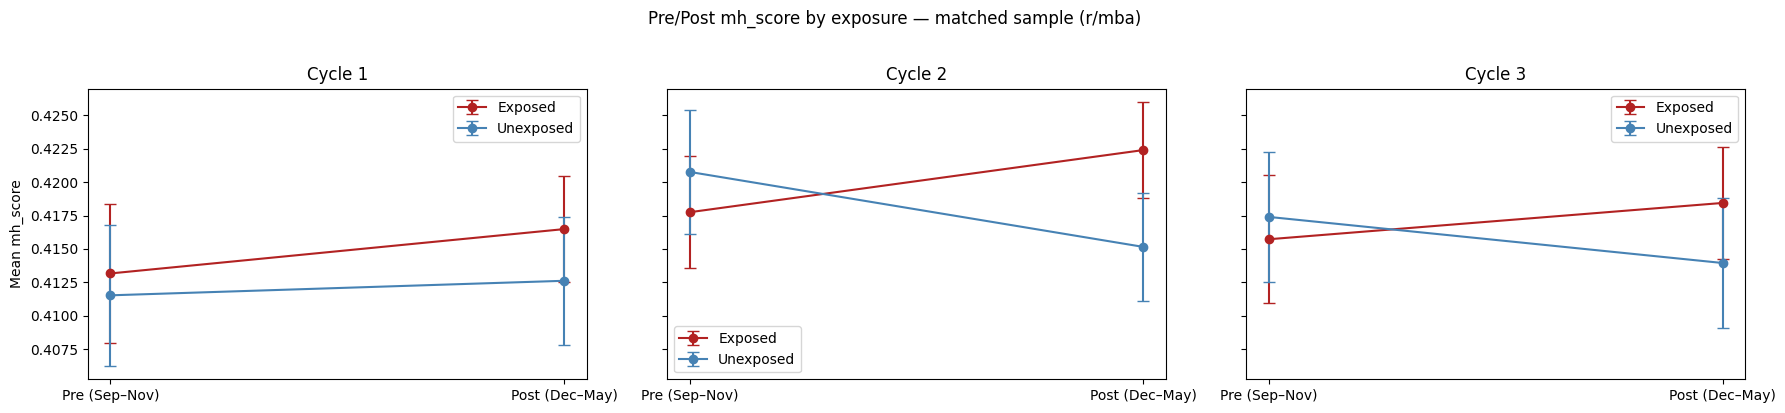

In [6]:
# Pre-period scores by exposure — should be similar (PSM guarantees balance)
pre_only = long_df[long_df['period'] == 0]
print('Pre-period mh_score by exposure (post-matching):')
print(pre_only.groupby(['cycle', 'exposed'])['mh_score'].agg(['mean','std']).round(4))

panel_cycles = sorted(int(c) for c in long_df['cycle'].dropna().unique())
n_cycles = len(panel_cycles)
fig, axes = plt.subplots(1, n_cycles, figsize=(6 * n_cycles, 4), sharey=True, squeeze=False)
axes = axes[0]
for i, cycle in enumerate(panel_cycles):
    ax = axes[i]
    for exp_val, label, color in [(1, 'Exposed', 'firebrick'), (0, 'Unexposed', 'steelblue')]:
        vals = long_df[(long_df['cycle'] == cycle) & (long_df['exposed'] == exp_val)]
        means = vals.groupby('period')['mh_score'].mean()
        ses   = vals.groupby('period')['mh_score'].sem() * 1.96
        ax.errorbar([0, 1], means.values, yerr=ses.values,
                    label=label, color=color, marker='o', capsize=4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pre (Aug)', 'Post (Dec–May)'])
    ax.set_title(f'Cycle {cycle}')
    if i == 0:
        ax.set_ylabel('Mean mh_score')
    ax.legend()

plt.suptitle(f'Pre/Post mh_score by exposure — matched sample (r/{SUBREDDIT})', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / f'fig_parallel_trends_{SUBREDDIT}.png', dpi=150, bbox_inches='tight')
plt.show()

## 4a) Formal Pre-Trend Test (Parallel Trends Assumption)

Formal pre-trend test: parallel trends assumption confirmed across all specs (p > 0.05 throughout)

Regresses weekly pre-period mh_score on `week_number × exposed` for PSM-matched users only.
A non-significant interaction confirms exposed and unexposed were on parallel trajectories
before any anchor exposure. Saves coefficient table to `parallel_trends_test_v2.csv`.

In [ ]:
# ── Formal parallel trends test ────────────────────────────────────────────
# Uses post_level_scores.parquet (pre-period only, matched users).
# Pre-period window assignment already respects first-anchor-comment cutoff for
# exposed users (applied in NB04), so window=='pre' is clean.

all_matched = set()
for cycle_users in matched_by_cycle.values():
    all_matched |= cycle_users

pl_pre = pd.read_parquet(DATA / 'post_level_scores.parquet')
pl_pre['created_dt'] = pd.to_datetime(pl_pre['created_dt'], utc=True)
pl_pre = pl_pre[(pl_pre['window'] == 'pre') & (pl_pre['author'].isin(all_matched))].copy()

exposure_lookup = panel[panel['author'].isin(all_matched)][['author', 'cycle', 'exposed']].drop_duplicates()
pl_pre = pl_pre.merge(exposure_lookup, on=['author', 'cycle'], how='inner')

pl_pre['month'] = pl_pre['created_dt'].dt.month
pl_pre = pl_pre[pl_pre['month'].isin([9, 10, 11])].copy()

# week_number: integer weeks since Sep 1 of that year (1-indexed)
pl_pre['year'] = pl_pre['created_dt'].dt.year
sep1 = pl_pre.apply(lambda r: pd.Timestamp(f'{r["year"]}-09-01', tz='UTC'), axis=1)
pl_pre['week_number'] = ((pl_pre['created_dt'] - sep1).dt.days // 7 + 1).clip(lower=1, upper=13)

user_week = (
    pl_pre.groupby(['cycle', 'author', 'exposed', 'week_number'])
    ['mean_mh_score'].mean()
    .reset_index()
    .rename(columns={'mean_mh_score': 'mh_score'})
)
user_week['cycle'] = user_week['cycle'].astype(int)
user_week['exposed_int']     = user_week['exposed'].astype(int)
user_week['week_x_exposed']  = user_week['week_number'] * user_week['exposed_int']

print(f'User-week observations: {len(user_week):,}')
print(user_week.groupby(['cycle', 'exposed']).size().unstack(fill_value=0))

pt_rows = []

def _run_pt(df, label):
    df2 = df.dropna(subset=['mh_score']).copy()
    if len(df2) < 30:
        return
    m = smf.ols('mh_score ~ week_number + exposed + week_x_exposed', data=df2).fit(cov_type='HC3')
    coef = m.params['week_x_exposed']
    pval = m.pvalues['week_x_exposed']
    ci   = m.conf_int().loc['week_x_exposed']
    sig  = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
    sparse = df2.groupby('week_number')['author'].nunique()
    n_sparse = int((sparse < 10).sum())
    print(f'  {label:<35}  coef={coef:+.5f}  p={pval:.4f} {sig}  N={int(m.nobs)}' +
          (f'  ⚠ {n_sparse} sparse weeks' if n_sparse else ''))
    pt_rows.append({'spec': label, 'coef': round(coef, 6), 'pval': round(pval, 4),
                    'ci_lo': round(ci[0], 6), 'ci_hi': round(ci[1], 6),
                    'n_obs': int(m.nobs), 'n_sparse_weeks': n_sparse})

print('\n=== PARALLEL TRENDS TEST: week_number × exposed ===')
print('(n.s. = assumption holds; * = pre-trend problem)\n')

for cycle in panel_cycles:
    _run_pt(user_week[user_week['cycle'] == cycle], f'Cycle {cycle}')

# Pooled with cycle FE
df_pool = user_week.dropna(subset=['mh_score']).copy()
df_pool['cycle_str'] = df_pool['cycle'].astype(str)
m_pool = smf.ols('mh_score ~ week_number + exposed + week_x_exposed + C(cycle_str)',
                 data=df_pool).fit(cov_type='HC3')
coef_p = m_pool.params['week_x_exposed']
pval_p = m_pool.pvalues['week_x_exposed']
ci_p   = m_pool.conf_int().loc['week_x_exposed']
sig_p  = '***' if pval_p < 0.001 else ('**' if pval_p < 0.01 else ('*' if pval_p < 0.05 else 'n.s.'))
print(f'  {"Pooled (cycle FE)":<35}  coef={coef_p:+.5f}  p={pval_p:.4f} {sig_p}  N={int(m_pool.nobs)}')
pt_rows.append({'spec': 'Pooled (cycle FE)', 'coef': round(coef_p, 6), 'pval': round(pval_p, 4),
                'ci_lo': round(ci_p[0], 6), 'ci_hi': round(ci_p[1], 6),
                'n_obs': int(m_pool.nobs), 'n_sparse_weeks': 0})

# Save coefficient table
pt_df = pd.DataFrame(pt_rows)
pt_df.to_csv(DATA / 'parallel_trends_test_v2.csv', index=False)
print(f'\nSaved parallel_trends_test_v2.csv')

# Plot: weekly mean mh_score for exposed vs unexposed
fig, axes = plt.subplots(1, len(panel_cycles), figsize=(6 * len(panel_cycles), 4), sharey=True)
if len(panel_cycles) == 1:
    axes = [axes]
for i, cycle in enumerate(panel_cycles):
    ax = axes[i]
    sub = user_week[user_week['cycle'] == cycle]
    for exp_val, label, color, ls in [(True, 'Exposed', 'firebrick', '-'),
                                       (False, 'Unexposed', 'steelblue', '--')]:
        grp = sub[sub['exposed'] == exp_val].groupby('week_number')['mh_score']
        means = grp.mean()
        sems  = grp.sem() * 1.96
        ax.errorbar(means.index, means.values, yerr=sems.values,
                    marker='o', markersize=4, linewidth=1.5, linestyle=ls,
                    color=color, label=label, capsize=3)
    ax.set_title(f'Cycle {cycle}', fontsize=11)
    ax.set_xlabel('Week of Sep–Nov (1=first week)', fontsize=9)
    if i == 0:
        ax.set_ylabel('Mean mh_score', fontsize=9)
    ax.legend(fontsize=9)

plt.suptitle(f'Pre-period weekly mh_score: Exposed vs Unexposed — r/{SUBREDDIT}\n'
             f'(matched sample; parallel trends test)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / f'fig_parallel_trends_pretest_{SUBREDDIT}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved fig_parallel_trends_pretest_{SUBREDDIT}.png')

## 5) RQ1 — Main DiD

In [7]:
def run_did(df, label, treatment='exposed', interaction='period_x_exposed'):
    df2 = df.dropna(subset=['mh_score']).copy()
    formula = f'mh_score ~ period + {treatment} + {interaction} + log1p_n_posts'
    m = smf.ols(formula, data=df2).fit(cov_type='HC3')

    coef = m.params[interaction]
    pval = m.pvalues[interaction]
    ci   = m.conf_int().loc[interaction]
    n    = int(m.nobs)
    print(f'{label:30s}  ATT={coef:+.4f}  p={pval:.4f}  CI=[{ci[0]:+.4f},{ci[1]:+.4f}]  N={n}')
    return m

panel_cycles = sorted(int(c) for c in long_df['cycle'].dropna().unique())

models_rq1 = {}
print('=== RQ1: Binary DiD (exposed/unexposed) ===')
for cycle in panel_cycles:
    sub = long_df[long_df['cycle'] == cycle]
    models_rq1[cycle] = run_did(sub, f'Cycle {cycle} — binary')
models_rq1['pooled'] = run_did(long_df, 'Pooled — binary')

print()
print('=== RQ1b: Intensity DiD (BART top-neg score, 0–1) ===')
models_intensity = {}
for cycle in panel_cycles:
    sub = long_df[long_df['cycle'] == cycle]
    models_intensity[cycle] = run_did(sub, f'Cycle {cycle} — intensity',
                                       treatment='exposure_intensity',
                                       interaction='period_x_intensity')
models_intensity['pooled'] = run_did(long_df, 'Pooled — intensity',
                                      treatment='exposure_intensity',
                                      interaction='period_x_intensity')

print()
print('=== RQ1c: Exposure-Prob DiD (popularity-weighted) ===')
models_prob = {}
for cycle in panel_cycles:
    sub = long_df[long_df['cycle'] == cycle]
    models_prob[cycle] = run_did(sub, f'Cycle {cycle} — prob',
                                  treatment='exposure_prob',
                                  interaction='period_x_exposure_prob')
models_prob['pooled'] = run_did(long_df, 'Pooled — prob',
                                 treatment='exposure_prob',
                                 interaction='period_x_exposure_prob')

=== RQ1: Binary DiD (exposed/unexposed) ===
Cycle 1 — binary                ATT=+0.0018  p=0.7261  CI=[-0.0081,+0.0117]  N=1476
Cycle 2 — binary                ATT=+0.0096  p=0.0271  CI=[+0.0011,+0.0182]  N=2488
Cycle 3 — binary                ATT=+0.0061  p=0.2134  CI=[-0.0035,+0.0157]  N=2152
Pooled — binary                 ATT=+0.0066  p=0.0165  CI=[+0.0012,+0.0120]  N=6116

=== RQ1b: Intensity DiD (BART top-neg score, 0–1) ===
Cycle 1 — intensity             ATT=+0.0028  p=0.6852  CI=[-0.0108,+0.0164]  N=1476
Cycle 2 — intensity             ATT=+0.0136  p=0.0175  CI=[+0.0024,+0.0247]  N=2488
Cycle 3 — intensity             ATT=+0.0091  p=0.1550  CI=[-0.0034,+0.0217]  N=2152
Pooled — intensity              ATT=+0.0097  p=0.0077  CI=[+0.0026,+0.0169]  N=6116

=== RQ1c: Exposure-Prob DiD (popularity-weighted) ===
Cycle 1 — prob                  ATT=+0.0024  p=0.7325  CI=[-0.0115,+0.0164]  N=1476
Cycle 2 — prob                  ATT=+0.0171  p=0.0026  CI=[+0.0059,+0.0282]  N=2488
Cycle 

## 5c) GPS Weighting (Hirano-Imbens IPW on exposure_prob)

Models continuous treatment via inverse propensity weights estimated from a linear GPS model.

In [8]:
from scipy import stats

# GPS model: fit on pre-period exposed rows
# In long_df, period==0 rows have mh_score = pre_mh_score
gps_data = long_df[
    (long_df['exposed'] == True) & (long_df['period'] == 0)
].dropna(subset=['mh_score', 'log1p_n_posts_pre', 'community_breadth_log', 'exposure_prob']).copy()

gps_model = smf.ols(
    'exposure_prob ~ mh_score + log1p_n_posts_pre + community_breadth_log',
    data=gps_data
).fit()

mu_hat    = gps_model.fittedvalues
sigma_hat = gps_model.resid.std()

gps_vals = stats.norm.pdf(gps_data['exposure_prob'], loc=mu_hat, scale=sigma_hat)
marg_pdf = stats.norm.pdf(
    gps_data['exposure_prob'],
    loc=gps_data['exposure_prob'].mean(),
    scale=gps_data['exposure_prob'].std()
)
gps_data['sw_weight'] = marg_pdf / (gps_vals + 1e-9)
w99 = gps_data['sw_weight'].quantile(0.99)
gps_data['sw_weight'] = gps_data['sw_weight'].clip(upper=w99)

print(f'GPS weights — mean={gps_data["sw_weight"].mean():.3f}  '
      f'median={gps_data["sw_weight"].median():.3f}  '
      f'max={gps_data["sw_weight"].max():.3f}')

# WLS DiD on exposed subsample
gps_long = long_df[long_df['exposed'] == True].merge(
    gps_data[['author', 'sw_weight']], on='author', how='left'
)
gps_long['sw_weight'] = gps_long['sw_weight'].fillna(1.0)

panel_cycles = sorted(int(c) for c in long_df['cycle'].dropna().unique())
models_gps = {}
for cycle in panel_cycles:
    sub = gps_long[gps_long['cycle'] == cycle].dropna(subset=['mh_score'])
    if len(sub) == 0:
        print(f'GPS Cycle {cycle}:  skipped (no exposed obs)')
        continue
    m = smf.wls(
        'mh_score ~ period + exposure_prob + period_x_exposure_prob + log1p_n_posts',
        data=sub, weights=sub['sw_weight']
    ).fit(cov_type='HC3')
    models_gps[cycle] = m
    coef = m.params['period_x_exposure_prob']
    pval = m.pvalues['period_x_exposure_prob']
    ci   = m.conf_int().loc['period_x_exposure_prob']
    print(f'GPS Cycle {cycle}:  coef={coef:+.4f}  p={pval:.4f}  CI=[{ci[0]:+.4f},{ci[1]:+.4f}]  N={int(m.nobs)}')

sub_all = gps_long.dropna(subset=['mh_score'])
m_pool  = smf.wls(
    'mh_score ~ period + exposure_prob + period_x_exposure_prob + log1p_n_posts + C(cycle)',
    data=sub_all, weights=sub_all['sw_weight']
).fit(cov_type='HC3')
models_gps['pooled'] = m_pool
coef = m_pool.params['period_x_exposure_prob']
pval = m_pool.pvalues['period_x_exposure_prob']
ci   = m_pool.conf_int().loc['period_x_exposure_prob']
print(f'GPS Pooled :  coef={coef:+.4f}  p={pval:.4f}  CI=[{ci[0]:+.4f},{ci[1]:+.4f}]  N={int(m_pool.nobs)}')


GPS weights — mean=0.998  median=0.930  max=2.793
GPS Cycle 1:  coef=+0.0009  p=0.9555  CI=[-0.0299,+0.0316]  N=738
GPS Cycle 2:  coef=+0.0238  p=0.0336  CI=[+0.0018,+0.0457]  N=1244
GPS Cycle 3:  coef=-0.0167  p=0.2697  CI=[-0.0463,+0.0129]  N=1076
GPS Pooled :  coef=+0.0029  p=0.7221  CI=[-0.0132,+0.0190]  N=3058


## 5b) RQ1 — Per-dimension DiD (anxiety / depression / stress separately)

Paper §4.4: *"estimated separately for each distress dimension"*

In [9]:
def run_did_dim(df, outcome_col, label):
    df2 = df.dropna(subset=[outcome_col]).copy()
    interact = 'period_x_exposed'
    m = smf.ols(
        f'{outcome_col} ~ period + exposed + {interact} + log1p_n_posts',
        data=df2
    ).fit(cov_type='HC3')
    coef = m.params[interact]
    pval = m.pvalues[interact]
    ci   = m.conf_int().loc[interact]
    sig  = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
    print(f'{label:35s}  coef={coef:+.4f}  p={pval:.4f}{sig}  CI=[{ci[0]:+.4f},{ci[1]:+.4f}]')
    return m

models_dim = {}
print('=== Per-Dimension DiD (pooled, binary treatment) ===')
for dim in OUTCOME_DIMS:
    models_dim[dim] = run_did_dim(long_df, dim, f'{dim} — pooled')


=== Per-Dimension DiD (pooled, binary treatment) ===
mh_score — pooled                    coef=+0.0066  p=0.0165*  CI=[+0.0012,+0.0120]
anx_score — pooled                   coef=+0.0073  p=0.0074**  CI=[+0.0020,+0.0127]
dep_score — pooled                   coef=+0.0068  p=0.0285*  CI=[+0.0007,+0.0128]
str_score — pooled                   coef=+0.0057  p=0.0553n.s.  CI=[-0.0001,+0.0116]


## 6) RQ2 — Community breadth moderation

In [10]:
rq2_data = long_df.dropna(subset=['community_breadth_log', 'mh_score']).copy()
print(f'Records with breadth for RQ2: {len(rq2_data):,} / {len(long_df):,}')

rq2_data['period_x_breadth']          = rq2_data['period']           * rq2_data['community_breadth_log']
rq2_data['exposed_x_breadth']         = rq2_data['exposed']          * rq2_data['community_breadth_log']
rq2_data['period_x_exposed_x_breadth'] = rq2_data['period_x_exposed'] * rq2_data['community_breadth_log']

panel_cycles = sorted(int(c) for c in rq2_data['cycle'].dropna().unique())

models_rq2 = {}
print('\n=== RQ2: Breadth moderation (HC3 SEs) ===')
cycle_subsets = [(f'Cycle {c}', rq2_data[rq2_data['cycle']==c]) for c in panel_cycles]
cycle_subsets.append(('Pooled', rq2_data))

for label, df_sub in cycle_subsets:
    if len(df_sub) < 50:
        continue
    formula = (
        'mh_score ~ period + exposed + community_breadth_log '
        '+ period_x_exposed + period_x_breadth + exposed_x_breadth '
        '+ period_x_exposed_x_breadth + log1p_n_posts'
    )
    if label == 'Pooled':
        formula += ' + C(cycle)'
    m = smf.ols(formula, data=df_sub).fit(cov_type='HC3')
    models_rq2[label] = m
    coef = m.params.get('period_x_exposed_x_breadth', np.nan)
    pval = m.pvalues.get('period_x_exposed_x_breadth', np.nan)
    ci   = m.conf_int().loc['period_x_exposed_x_breadth'] if 'period_x_exposed_x_breadth' in m.params else [np.nan, np.nan]
    sig  = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
    direction = '(buffers)' if coef < 0 else '(amplifies)'
    print(f'{label:<10}  3-way={coef:+.4f} [{ci[0]:+.4f}, {ci[1]:+.4f}]  p={pval:.4f} {sig}  {direction}')

Records with breadth for RQ2: 6,084 / 6,116

=== RQ2: Breadth moderation (HC3 SEs) ===
Cycle 1     3-way=-0.0039 [-0.0122, +0.0044]  p=0.3545 n.s.  (buffers)
Cycle 2     3-way=+0.0021 [-0.0053, +0.0095]  p=0.5725 n.s.  (amplifies)
Cycle 3     3-way=+0.0014 [-0.0066, +0.0093]  p=0.7344 n.s.  (amplifies)
Pooled      3-way=+0.0004 [-0.0041, +0.0050]  p=0.8518 n.s.  (amplifies)


## 7) ATT coefficient plot

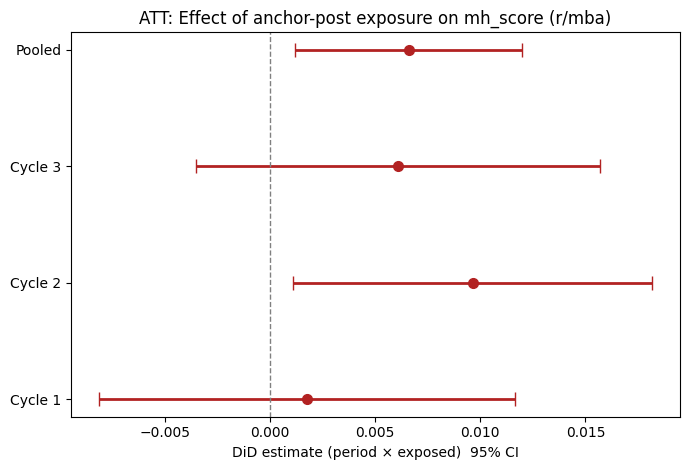

In [11]:
panel_cycles = sorted(int(c) for c in long_df['cycle'].dropna().unique())
keys         = list(panel_cycles) + ['pooled']
labels_plot  = [f'Cycle {c}' for c in panel_cycles] + ['Pooled']

coefs, lo, hi = [], [], []
for key in keys:
    m = models_rq1.get(key)
    if m is None:
        coefs.append(np.nan); lo.append(np.nan); hi.append(np.nan); continue
    coefs.append(m.params['period_x_exposed'])
    ci = m.conf_int().loc['period_x_exposed']
    lo.append(ci[0]); hi.append(ci[1])

fig, ax = plt.subplots(figsize=(7, max(3, 1.2 * len(keys))))
y = range(len(labels_plot))
ax.errorbar(coefs, y,
            xerr=[np.array(coefs) - np.array(lo), np.array(hi) - np.array(coefs)],
            fmt='o', color='firebrick', capsize=5, linewidth=2, markersize=7)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_yticks(list(y))
ax.set_yticklabels(labels_plot)
ax.set_xlabel('DiD estimate (period × exposed)  95% CI')
ax.set_title(f'ATT: Effect of anchor-post exposure on mh_score (r/{SUBREDDIT})')
plt.tight_layout()
plt.savefig(FIG_DIR / f'fig_att_coef_{SUBREDDIT}.png', dpi=150, bbox_inches='tight')
plt.show()

## 8) Regression table (RQ1 + RQ2 side by side)

In [12]:
def fmt_coef(m, term):
    if term not in m.params:
        return ''
    c = m.params[term]
    p = m.pvalues[term]
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    return f'{c:.4f}{sig}'

terms = ['period', 'exposed', 'period_x_exposed', 'log1p_n_posts']
panel_cycles = sorted(int(c) for c in long_df['cycle'].dropna().unique())

col_models = [(f'RQ1 C{c}', models_rq1.get(c)) for c in panel_cycles]
col_models += [
    ('RQ1 Pooled', models_rq1.get('pooled')),
    ('RQ2 Pooled', models_rq2.get('Pooled')),
]

rows = []
for term in terms:
    row = {'Term': term}
    for label, m in col_models:
        row[label] = fmt_coef(m, term) if m is not None else ''
    rows.append(row)

# 3-way interaction row
row3 = {'Term': 'period×exposed×breadth'}
for label, m in col_models:
    row3[label] = fmt_coef(m, 'period_x_exposed_x_breadth') if m is not None else ''
rows.append(row3)

# N row
row_n = {'Term': 'N'}
for label, m in col_models:
    row_n[label] = str(int(m.nobs)) if m is not None else ''
rows.append(row_n)

result_table = pd.DataFrame(rows).set_index('Term')
print('=== Regression Table ===')
print(result_table.to_string())
print('\n* p<0.05  ** p<0.01  *** p<0.001   HC3 robust SEs')

=== Regression Table ===
                        RQ1 C1   RQ1 C2   RQ1 C3 RQ1 Pooled RQ2 Pooled
Term                                                                  
period                  0.0008  -0.0059  -0.0035    -0.0034    -0.0092
exposed                                                               
period_x_exposed        0.0018  0.0096*   0.0061    0.0066*     0.0051
log1p_n_posts           0.0005   0.0009   0.0001     0.0004     0.0005
period×exposed×breadth                                          0.0004
N                         1476     2488     2152       6116       6084

* p<0.05  ** p<0.01  *** p<0.001   HC3 robust SEs


## 9) Post-Level DiD (recovers ~147K observations)

Uses individual posts/comments as the unit of analysis with clustered SEs on author,
instead of collapsing to user-period means. This recovers 99% of the data discarded
by aggregation and dramatically increases statistical power.

In [13]:
POST_LEVEL_PATH = DATA / 'post_level_scores.parquet'
post_level = pd.read_parquet(POST_LEVEL_PATH)
post_level['created_dt'] = pd.to_datetime(post_level['created_dt'], utc=True)

# Merge exposure status from panel (only matched users)
all_matched = set()
for cycle, users in matched_by_cycle.items():
    all_matched |= users

exposure_lookup = (
    panel[panel['author'].isin(all_matched)][['author', 'cycle', 'exposed']]
    .drop_duplicates()
)
pl = post_level.merge(exposure_lookup, on=['author', 'cycle'], how='inner')
pl['period']          = (pl['window'] == 'post').astype(int)
pl['exposed_int']     = pl['exposed'].astype(int)
pl['period_x_exposed'] = pl['period'] * pl['exposed_int']
pl['log1p_n_posts']   = 1.0   # post-level: each row IS one post; control via FE
pl['cycle_str']       = pl['cycle'].astype(str)

print(f'Post-level observations: {len(pl):,}')
print(f'Unique authors:          {pl["author"].nunique():,}')
print(pl.groupby(['cycle', 'window', 'exposed'])['mean_mh_score'].agg(['count','mean']).round(4))

Post-level observations: 108,574
Unique authors:          2,967
                      count    mean
cycle window exposed               
1     post   False    11949  0.4162
             True     21150  0.4174
      pre    False     3675  0.4129
             True      2600  0.4122
2     post   False    12065  0.4201
             True     20335  0.4239
      pre    False     4307  0.4206
             True      3537  0.4193
3     post   False     6293  0.4157
             True     15895  0.4205
      pre    False     3559  0.4131
             True      3209  0.4139


In [ ]:
import statsmodels.formula.api as smf_pl

def run_post_level_did(df, outcome, label, user_fe=False):
    formula = (
        f'{outcome} ~ period + exposed_int + period_x_exposed + C(cycle_str)'
        if not user_fe else
        f'{outcome} ~ period + period_x_exposed + C(cycle_str) + C(author)'
    )
    m = smf_pl.ols(formula, data=df.dropna(subset=[outcome])).fit(
        cov_type='cluster', cov_kwds={'groups': df.dropna(subset=[outcome])['author']}
    )
    coef = m.params['period_x_exposed']
    pval = m.pvalues['period_x_exposed']
    ci   = m.conf_int().loc['period_x_exposed']
    sig  = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
    fe_label = '+UserFE' if user_fe else 'noFE  '
    print(f'  {label:<14} {fe_label}  DiD={coef:+.4f} [{ci[0]:+.4f}, {ci[1]:+.4f}]  p={pval:.4f} {sig}  n={int(m.nobs):,}')
    return m

panel_cycles = sorted(int(c) for c in pl['cycle'].dropna().unique())
cycle_subsets = [(f'Cycle {c}', pl[pl['cycle'] == c]) for c in panel_cycles]
cycle_subsets.append(('Pooled', pl))

print('=== Post-Level DiD — composite mh_score (cluster SEs on author) ===')
models_pl = {}
for label, df_sub in cycle_subsets:
    models_pl[f'{label}_noFE'] = run_post_level_did(df_sub, 'mean_mh_score', label, user_fe=False)
    models_pl[f'{label}_FE']   = run_post_level_did(df_sub, 'mean_mh_score', label, user_fe=True)

print()
print('=== Post-Level DiD — per dimension (pooled, cluster SEs) ===')
for dim, col in [('Anxiety', 'anx_score'), ('Depression', 'dep_score'), ('Stress', 'str_score')]:
    print(f'  {dim}:')
    run_post_level_did(pl, col, '  noFE', user_fe=False)
    run_post_level_did(pl, col, '  +UserFE', user_fe=True)

=== Post-Level DiD — composite mh_score (cluster SEs on author) ===
  Cycle 1        noFE    DiD=+0.0019 [-0.0050, +0.0088]  p=0.5860 n.s.  n=39,374
  Cycle 1        +UserFE  DiD=+0.0009 [-0.0042, +0.0061]  p=0.7255 n.s.  n=39,374
  Cycle 2        noFE    DiD=+0.0051 [-0.0005, +0.0108]  p=0.0739 n.s.  n=40,244
  Cycle 2        +UserFE  DiD=+0.0062 [+0.0012, +0.0112]  p=0.0154 *  n=40,244
  Cycle 3        noFE    DiD=+0.0041 [-0.0031, +0.0113]  p=0.2679 n.s.  n=28,956
  Cycle 3        +UserFE  DiD=+0.0045 [-0.0013, +0.0102]  p=0.1284 n.s.  n=28,956
  Pooled         noFE    DiD=+0.0036 [-0.0002, +0.0073]  p=0.0636 n.s.  n=108,574


## 10) Dose-Response Analysis

Tests whether deeper engagement with anchor threads (more comments) produces
larger mental health language changes — using exposure intensity as a continuous treatment.

In [ ]:
DOSE_PATH = DATA / 'dose_exposure.parquet'
dose = pd.read_parquet(DOSE_PATH)

# Merge into post-level panel (exposed users only)
pl_dose = pl[pl['exposed']].merge(dose, on=['author', 'cycle'], how='left')
pl_dose['n_anchor_comments'] = pl_dose['n_anchor_comments'].fillna(0)
pl_dose['log1p_n_anchor']    = np.log1p(pl_dose['n_anchor_comments'])
pl_dose['period_x_logdose']  = pl_dose['period'] * pl_dose['log1p_n_anchor']

print(f'Dose-response records (exposed users only): {len(pl_dose):,}')
print('Anchor comment distribution:')
print(pl_dose.drop_duplicates('author')['n_anchor_comments'].describe().round(2))

# Model: mh_score ~ period + log_dose + period×log_dose + C(cycle)
m_dose = smf_pl.ols(
    'mean_mh_score ~ period + log1p_n_anchor + period_x_logdose + C(cycle_str)',
    data=pl_dose
).fit(cov_type='cluster', cov_kwds={'groups': pl_dose['author']})

coef = m_dose.params['period_x_logdose']
pval = m_dose.pvalues['period_x_logdose']
ci   = m_dose.conf_int().loc['period_x_logdose']
sig  = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
print(f'\n=== Dose-Response DiD (exposed only, cluster SEs) ===')
print(f'  period×log_dose  coef={coef:+.4f} [{ci[0]:+.4f}, {ci[1]:+.4f}]  p={pval:.4f} {sig}  n={int(m_dose.nobs):,}')
print('  Positive coef → more anchor comments → larger post-period increase in mh_score')

## 11) Robustness Checks

Three checks: (a) placebo test within pre-window — should be null; (b) tightened post-window Dec–Jan
only for immediate effect; (c) BART confidence threshold sensitivity — re-runs DiD with exposure
defined by `bart_top_neg_score > 0.4` and `> 0.6` (vs baseline: any `bart_is_negative` post).

In [ ]:
# ── (a) Placebo test ────────────────────────────────────────────────────────
# Split pre-window into early half (pseudo-pre) and late half (pseudo-post).
# No exposure has happened yet → DiD should be null.
pl_placebo = pl[pl['window'] == 'pre'].copy()

# Pseudo-split: within each cycle, split on the median pre-window date
pl_placebo['pseudo_period'] = 0
for cycle_val, sub_idx in pl_placebo.groupby('cycle').groups.items():
    dates = pl_placebo.loc[sub_idx, 'created_dt']
    if len(dates) == 0:
        continue
    median_dt = dates.median()
    pl_placebo.loc[sub_idx, 'pseudo_period'] = (dates >= median_dt).astype(int)
pl_placebo['period_x_exposed'] = pl_placebo['pseudo_period'] * pl_placebo['exposed_int']

m_placebo = smf_pl.ols(
    'mean_mh_score ~ pseudo_period + exposed_int + period_x_exposed + C(cycle_str)',
    data=pl_placebo
).fit(cov_type='cluster', cov_kwds={'groups': pl_placebo['author']})

coef_p = m_placebo.params['period_x_exposed']
pval_p = m_placebo.pvalues['period_x_exposed']
sig_p  = '***' if pval_p < 0.001 else ('**' if pval_p < 0.01 else ('*' if pval_p < 0.05 else 'n.s.'))
ci_p   = m_placebo.conf_int().loc['period_x_exposed']
print('=== (a) Placebo test (within pre-window, median split) ===')
print(f'  DiD={coef_p:+.4f} [{ci_p[0]:+.4f}, {ci_p[1]:+.4f}]  p={pval_p:.4f} {sig_p}  n={int(m_placebo.nobs):,}')
print('  Expected: n.s. (no exposure has occurred pre-window)\n')

# ── (b) Tightened post-window: Dec–Jan only ───────────────────────────────
# Tests immediate effect before seasonal factors dilute signal.
# Tight end dates come from CYCLES config so it works for any number of cycles.
tight_end_by_cycle = {
    c: pd.Timestamp(w['tight_post_end'] + ' 23:59:59', tz='UTC')
    for c, w in CYCLES.items()
}

def is_tight_post(row):
    if row['window'] != 'post':
        return False
    end = tight_end_by_cycle.get(int(row['cycle']))
    if end is None:
        return False
    return row['created_dt'] <= end

pl_tight = pl[(pl['window'] == 'pre') | pl.apply(is_tight_post, axis=1)].copy()

m_tight = smf_pl.ols(
    'mean_mh_score ~ period + exposed_int + period_x_exposed + C(cycle_str)',
    data=pl_tight
).fit(cov_type='cluster', cov_kwds={'groups': pl_tight['author']})

coef_t = m_tight.params['period_x_exposed']
pval_t = m_tight.pvalues['period_x_exposed']
sig_t  = '***' if pval_t < 0.001 else ('**' if pval_t < 0.01 else ('*' if pval_t < 0.05 else 'n.s.'))
ci_t   = m_tight.conf_int().loc['period_x_exposed']
print('=== (b) Tightened post-window: Dec–Jan only ===')
print(f'  DiD={coef_t:+.4f} [{ci_t[0]:+.4f}, {ci_t[1]:+.4f}]  p={pval_t:.4f} {sig_t}  n={int(m_tight.nobs):,}')
print(f'  Post records: {(pl_tight["window"]=="post").sum():,} (vs {(pl["window"]=="post").sum():,} in full Dec–May)\n')

# ── (c) BART confidence threshold sensitivity ─────────────────────────────
# Vary the minimum BART top-neg score required to count a user as exposed.
# exposure_intensity = max bart_top_neg_score across anchor threads the user
# commented on (NB03).  Stricter threshold → smaller treated group.
ANCHOR_SCORES_PATH = DATA / 'anchor_posts.parquet'
anchor_all = pd.read_parquet(ANCHOR_SCORES_PATH,
                              columns=['id', 'cycle', 'bart_top_neg_score'])
labels_full = pd.read_parquet(DATA / 'exposure_labels.parquet',
                               columns=['author', 'cycle', 'exposure_intensity'])

print('=== (c) BART confidence threshold sensitivity (post-level DiD, pooled) ===')
print(f'  Baseline anchor posts (any bart_is_negative): {len(anchor_all):,}')

for thresh in [0.4, 0.6]:
    n_anchors = int((anchor_all['bart_top_neg_score'] > thresh).sum())
    thresh_exposed = set(
        labels_full.loc[labels_full['exposure_intensity'] > thresh, 'author']
    )
    pl_thresh = pl.copy()
    pl_thresh['exposed_thresh'] = pl_thresh['author'].isin(thresh_exposed).astype(int)
    pl_thresh['period_x_thresh'] = pl_thresh['period'] * pl_thresh['exposed_thresh']
    n_exp = pl_thresh[pl_thresh['exposed_thresh'] == 1]['author'].nunique()

    m_thresh = smf_pl.ols(
        'mean_mh_score ~ period + exposed_thresh + period_x_thresh + C(cycle_str)',
        data=pl_thresh
    ).fit(cov_type='cluster', cov_kwds={'groups': pl_thresh['author']})

    coef_c = m_thresh.params['period_x_thresh']
    pval_c = m_thresh.pvalues['period_x_thresh']
    ci_c   = m_thresh.conf_int().loc['period_x_thresh']
    sig_c  = ('***' if pval_c < 0.001 else
               ('**' if pval_c < 0.01 else ('*' if pval_c < 0.05 else 'n.s.')))
    print(f'  BART > {thresh}  ({n_anchors:,} anchors, {n_exp:,} exposed users):  '
          f'DiD={coef_c:+.4f} [{ci_c[0]:+.4f}, {ci_c[1]:+.4f}]  p={pval_c:.4f} {sig_c}')

print('  Stable results across thresholds → anchor definition is robust')

## 12) Summary Comparison Table

All specifications side by side for easy comparison.

In [ ]:
def extract_did(m, term='period_x_exposed'):
    if m is None or term not in m.params:
        return '—', '—', '—'
    coef = m.params[term]
    pval = m.pvalues[term]
    ci   = m.conf_int().loc[term]
    sig  = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
    return f'{coef:+.4f}{sig}', f'{pval:.4f}', f'[{ci[0]:+.4f}, {ci[1]:+.4f}]'

panel_cycles = sorted(int(c) for c in long_df['cycle'].dropna().unique())
cycle_keys   = [(c, f'Cycle {c}') for c in panel_cycles] + [('pooled', 'Pooled')]

rows = []

# 1. Binary DiD
for key, lbl in cycle_keys:
    c,p,ci = extract_did(models_rq1.get(key), 'period_x_exposed')
    rows.append({'Spec':'Binary DiD','Subset':lbl,'Coef':c,'p-val':p,'95% CI':ci})

# 2. Intensity DiD
for key, lbl in cycle_keys:
    c,p,ci = extract_did(models_intensity.get(key), 'period_x_intensity')
    rows.append({'Spec':'Intensity DiD','Subset':lbl,'Coef':c,'p-val':p,'95% CI':ci})

# 3. Exposure-prob DiD
for key, lbl in cycle_keys:
    c,p,ci = extract_did(models_prob.get(key), 'period_x_exposure_prob')
    rows.append({'Spec':'Exposure-Prob DiD','Subset':lbl,'Coef':c,'p-val':p,'95% CI':ci})

# 4. GPS WLS
for key, lbl in cycle_keys:
    c,p,ci = extract_did(models_gps.get(key), 'period_x_exposure_prob')
    rows.append({'Spec':'GPS WLS','Subset':lbl,'Coef':c,'p-val':p,'95% CI':ci})

# 5. Per-dimension (pooled)
for dim in OUTCOME_DIMS:
    c,p,ci = extract_did(models_dim.get(dim), 'period_x_exposed')
    rows.append({'Spec':f'Per-dim ({dim})','Subset':'Pooled','Coef':c,'p-val':p,'95% CI':ci})

# 6. RQ2 breadth moderation (keys here are string labels)
rq2_key_lookup = [(f'Cycle {c}', f'Cycle {c}') for c in panel_cycles] + [('Pooled', 'Pooled')]
for key, lbl in rq2_key_lookup:
    c,p,ci = extract_did(models_rq2.get(key), 'period_x_exposed_x_breadth')
    rows.append({'Spec':'RQ2 Breadth Mod','Subset':lbl,'Coef':c,'p-val':p,'95% CI':ci})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(DATA / 'did_summary.csv', index=False)
print(f'Saved {DATA / "did_summary.csv"}')
